## Instruction for Assignment 2 Submission

- This is an individual assessment. Refrain from working in groups. We will use plagiarism detectors after the submission. So, do not engage in unethical activities.
- Name your jupyter notebook before the submission as `Assignment2_[StudentID].ipynb`. For instance: `Assignment2_A0123873A.ipynb`.
- Your solution notebook must contain the python code that we can run to verify the answers.
- For all open ended questions, you must limit your answers to 50 words or less. 
- Please submit the final and clean version of the code.
- **Do not delete the output blocks in your submission.**
- Late submissions will receive a penalty on the grade as follows:
  - late within 1 hour: 10% reduction in grade
  - late within 6 hours: 30% reduction in grade
  - late within 12 hours: 50% reduction in grade
  - late within 1 day: 70% reduction in grade
  - after 1 day: zero mark


  The dataset is available in the same folder as this assignment on Canvas, please download it before you work on the assignment.

## Preparation

### Dataset Description

Link to the original dataset : [German Credit Data](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

This dataset classifies people described by a set of attributes as good or bad credit risks. A subset of features are used for this assignment.

This research employed a binary variable, `Label` (1 = Good, 2 = Bad) , as the response variable (target). This study consists of the following explanatory variables :

* `Age`
* `Sex`
* `Job` (0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
* `Housing`
* `Saving accounts`
* `Checking account`
* `Credit amount`
* `Duration` (in months)
* `Purpose`


### Mount Google Drive


Use this mounting code if you are running this notebook on Google Colab.

Use `%cd` to change the directory (folder) where you save this assignment notebook. Save the dataset in the same directory as this notebook.

Below example shows that this notebook is saved in the `a2` folder of the user's Google Drive, with the folder path of `TA/IT5006/assignments/a2` folder.

In [1]:
#from google.colab import drive
#drive.mount('/content/gdrive')
#%cd /content/gdrive/MyDrive/TA/IT5006/assignments/a2

In [2]:
#!ls

### Load Library and Dataset

In [3]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
from matplotlib import pyplot
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import category_encoders as ce

# load additional libraries that you need for the assignment

In [4]:
#data = pd.read_csv('Assignment_2_dataset.csv')
data = pd.read_csv("German_Credit Dataset.csv")
#list_available_datasets()
#credit = fetch_ucirepo(id=144)
#X = credit.data.features 
#y = credit.data.targets
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Label             1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [5]:
#data.head()
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Label
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


## Question 1 - Exploratory Data Analysis (6 marks)

### Q1A (1 mark)

Count the number of unique categories for each categorical feature : `sex`, `job`, `housing`, `saving_accounts`, `checking_account`, `purpose`.

*Optional : you can list the categories out for your own sanity check.*

In [6]:
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
print(categorical_columns)

['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [7]:
for category in categorical_columns:
    
    unique_count = data[category].nunique()
    print(category, unique_count)

Sex 2
Housing 3
Saving accounts 4
Checking account 3
Purpose 8


### Q1B (1 mark)

Display statistical summary for each numerical features : `age`, `credit_amount`, `duration`.

In [8]:
numerical_columns = data.select_dtypes(exclude=['object']).columns.tolist()
print(numerical_columns)

['Age', 'Job', 'Credit amount', 'Duration', 'Label']


In [9]:
for category in numerical_columns:
    
    summary_stats = data[category].describe()
    print(category)
    print()
    print(summary_stats)
    print()
    

Age

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

Job

count    1000.000000
mean        1.904000
std         0.653614
min         0.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: Job, dtype: float64

Credit amount

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

Duration

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

Label

count    1000.000000
mean        1.300000
std         0.458487
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max     

### Q1C (2 marks)

1. Plot the distribution of each numerical feature by `label` to visualize overlapping distributions between different classes.

2. Analyse the distributions. Explain your insights on the observed trend or pattern and the possible reasons behind the insights.

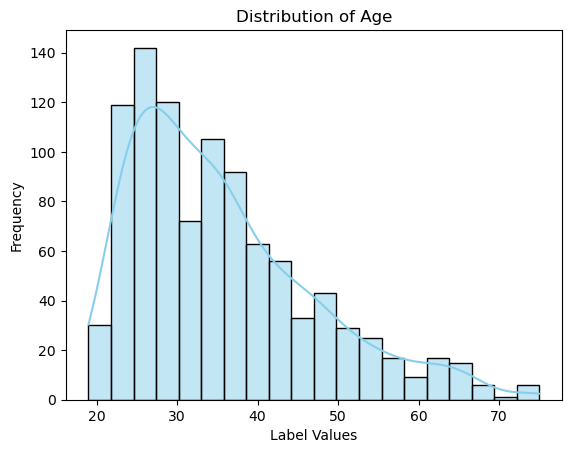

In [10]:
# YOUR CODE HERE
sns.histplot(data['Age'], kde=True, bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Label Values")
plt.ylabel("Frequency")
plt.show()

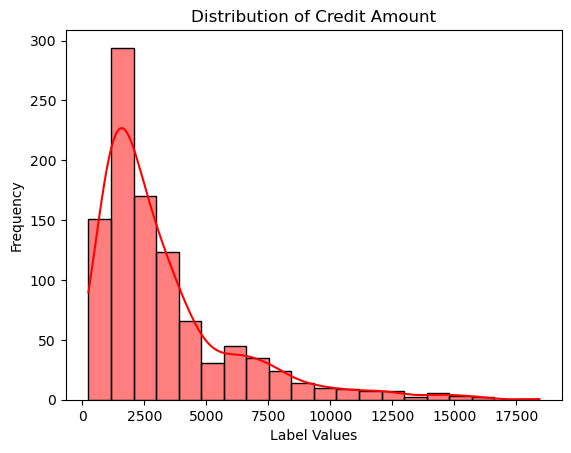

In [11]:
sns.histplot(data['Credit amount'], kde=True, bins=20, color="red", edgecolor="black")
plt.title("Distribution of Credit Amount")
plt.xlabel("Label Values")
plt.ylabel("Frequency")
plt.show()

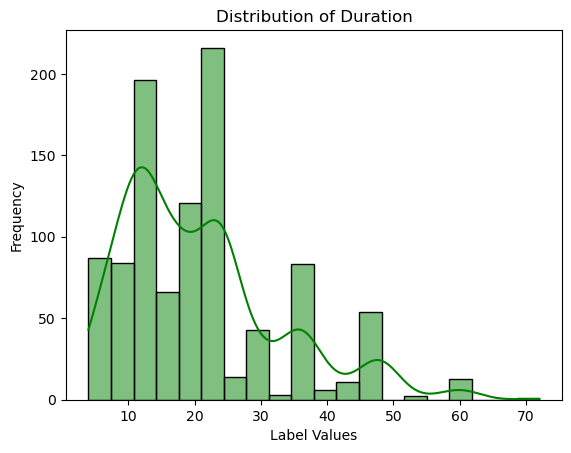

In [12]:
sns.histplot(data['Duration'], kde=True, bins=20, color="green", edgecolor="black")
plt.title("Distribution of Duration")
plt.xlabel("Label Values")
plt.ylabel("Frequency")
plt.show()

All the distributions roughly follow the Dagum Distribution. The Dagum Distribution is a normal distribution skewed to the left. The Dagum distribution is effective in modelling empirical income and wealth distributions. The skewness to the left and the tail to the right is an innate characteric of the data. Age, credit amount and duration taper off at higher values. Under normal circumstances, people will not borrow large amounts of money or for a long period of time. As people age, they will also borrow less as they retire and scale down their lifestyle expenditure.  

### Q1D (2 marks)

1. For the categorical features, aggregate the records where the **label equals to 2**, and calculate the percentage for each category.
2. Analyse the top category (category with the largest proportion) for each feature, explain the possible reasons/insights behind them.

In [13]:
# YOUR CODE HERE
label_equals_2 = data.query('Label == 2')
label_equals_2.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Label
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
4,53,male,2,free,little,little,4870,24,car,2
9,28,male,3,own,little,moderate,5234,30,car,2
10,25,female,2,rent,little,moderate,1295,12,car,2
11,24,female,2,rent,little,little,4308,48,business,2


In [14]:
for category in categorical_columns:
    catCol = label_equals_2[category]
    print()
    print(catCol.value_counts(normalize = True))
    print()


Sex
male      0.636667
female    0.363333
Name: proportion, dtype: float64


Housing
own     0.620000
rent    0.233333
free    0.146667
Name: proportion, dtype: float64


Saving accounts
little        0.809701
moderate      0.126866
quite rich    0.041045
rich          0.022388
Name: proportion, dtype: float64


Checking account
little      0.531496
moderate    0.413386
rich        0.055118
Name: proportion, dtype: float64


Purpose
car                    0.353333
radio/TV               0.206667
furniture/equipment    0.193333
business               0.113333
education              0.076667
repairs                0.026667
vacation/others        0.016667
domestic appliances    0.013333
Name: proportion, dtype: float64



# Write your answers here :
1 = Good Credit Risk, 2 = Bad Credit Risk. We are aggregating people with bad credit risk
2. The top category for each feature is as follows. 

For the gender category, males have a higher proportion (63.67%) of credit risk than females. This is to be expected, as across all societies, males still bear most of the financial burden of providing for the family.

For the housing category, people who own their homes have a higher proportion (62%) of bad credit risk. It is possible that in Germany, owning a home and making repayments on the mortgage is much more expensive than renting.

For savings account category, it is to be expected that people with little savings will have the highest proportion of bad credit risk as they may not cultivate the habit of controlling spending.

For the checking account category, people who have little money in the checking account have the highest proportion of bad credit risk. Since the checking account is a form of savings, the logic for the saving account applies.

For the purpose category, people who borrow to finance a car have the highest proportion of bad credit risk. A car is an expensive and depreciating asset and financing automobiles via loans can place people on financial strain.   

## Question 2 - Preprocessing (4 marks)

We deal with multiple sources of randomness during data analytics. It can be induced via data sampling or it can be induced via a learning algorithm. The reproucibility of the experiments becomes the key issue. We can overcome the reproducibility problem by setting the `seed` for (pseudo-)random number generators. You can read more about this [here](https://stackoverflow.com/questions/28064634/random-state-pseudo-random-number-in-scikit-learn).

Let's initialise the random state for our experiment. Every machine learning model in `sklearn` takes the random-state as one of its argument. Use `rng` wherever required.

In [15]:
rng = np.random.RandomState(42)

### Q2A (1 mark)

Split dataset into training and testing sets : `data_train` and `data_test` as a 80-20 split.

*Remember to use the random_state that we have defined earlier!*

In [16]:
# YOUR CODE HERE
target = data['Label'].copy()
target.head()

0    1
1    2
2    1
3    1
4    2
Name: Label, dtype: int64

In [17]:
data.drop(['Label'], axis=1, inplace=True)
numerical_columns.remove('Label')
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [18]:
data_train, data_test, y_train, y_test = train_test_split(data, target, test_size = 0.20, random_state = rng)

### Q2B (2 marks)

`sklearn - Pipeline` allows to write various data processing steps in a flexible and modular manner. Please read more about them [here](https://scikit-learn.org/stable/modules/compose.html). The website also provides plenty short examples to understand the pipeline.

Build a pipeline to preprocess all categorical features.

- Convert all categorical features to numerical by encoding them. Please treat missing value for every predictor as a new category for the respective predictor.
- Keep all numerical features as they are.

In [19]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Sample data

# Identify categorical features
#categorical_features = data.select_dtypes(include=['object']).columns.tolist()

# Preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value= 'missing')),  # Treat null and empty values as missing
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Convert categories to numeric
])

# Preprocessing for numerical features (no transformation)
numerical_transformer = 'passthrough'

# Combine transformations using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    
    ('cat', categorical_transformer, categorical_columns),
    ('num', numerical_transformer, numerical_columns)
])




### Q2C (1 mark)

Explain your reasonings of choosing the type of Encoder(s) you used to encode the categorical features.

Write your answers here :

Now let's use the data-preprocessing pipeline that we have defined in the earlier question. Ensure your preprocess is functional before you proceed.

In [20]:
X_train = preprocessor.fit_transform(data_train)
X_test =  preprocessor.fit_transform(data_test)

For the imputer, a strategy of constant was used. This transforms null and empty values in the category columns to the value 'missing'. Onehot encoding was then used to convert categorical data to numeric values. The numeric columns were left alone by the 'passthrough' transformer.

## Question 3 - Modeling (4 marks)

### Q3A (2 marks)

We fit two different classifiers on the training data.

* Logistic Regression Classifier with `max_iter=100`
* Random Forest Classifier with `n_estimators=100`

For each classifier, print the `classification_report` for training and test set.

*You can use `print()` to format the `classification_report` so it outputs a nice table format instead of raw string.*

In [21]:
# YOUR CODE HERE
training_pipeline_forest = Pipeline(steps=[
    ('classifier', RandomForestClassifier(n_estimators=100))
])
training_pipeline_forest.fit(X_train, y_train)
y_pred_forest = training_pipeline_forest.predict(X_test)
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           1       0.78      0.88      0.82       141
           2       0.57      0.39      0.46        59

    accuracy                           0.73       200
   macro avg       0.68      0.63      0.64       200
weighted avg       0.72      0.73      0.72       200



In [22]:
# YOUR CODE HERE
training_pipeline_logistic = Pipeline(steps=[
    ('classifier', LogisticRegression(max_iter=100))
])
training_pipeline_logistic.fit(X_train, y_train)
y_pred_logistic = training_pipeline_logistic.predict(X_test)
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           1       0.77      0.88      0.82       141
           2       0.56      0.37      0.45        59

    accuracy                           0.73       200
   macro avg       0.67      0.63      0.64       200
weighted avg       0.71      0.73      0.71       200



C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Q3B (2 marks)
Interpret the results above and answer the following questions :

1. Compare quantitatively the **test** performance of Logistic Regression and Random Forest models from their `classification_report`, which model is better at detecting bad customers (Label 2) ?

  You do not have to compare all test metrics. Please only choose the metric(s) that can help you to answer the question in the context of financial risk modeling.

2. Which model suffers from overfitting ? Suggest at least one method to reduce overfitting in this model. (no code implementation is needed, text explanation is sufficient)

1. Random Forest was slightly better than Logistic regression in predicting bad customers, with a higher precision and recall value.

2. Logistic Regression suffers from overfitting. Using cross-validation during training helps ensure that the model generalizes well to unseen data.

## Question 4 - Model Validation (3 marks)

### Q4A (1 mark)

Label 2 represents people who could not pay back the loan (i.e. default). In the context of financial risk modeling, it is better to classify "a good customer as bad" than "a bad customer as good".

Following is a cost matrix that show the cost of mis-classification:

**Cost Matrix**

| Actual \ Predicted | 1 | 2 |
|--------------------|---|---|
| 1                  | 0 | 1 |
| 2                  | 5 | 0 |

In words, the cost of misclassifying a good customer is 1 unit whereas the the cost of misclassifying a bad customer is 5 units.

In [23]:
def classification_cost(y_pred, y_true):

    y_pred = [element for element in y_pred]
    y_true = [element for element in y_true]
    
    length = len(y_pred)
    cost = 0
    
    for i in range(length):

        if y_pred[i] == 1 and y_true[i] == 2:

            cost += 5

        elif y_pred[i] == 2 and  y_true[i] == 1:

            cost += 1
    
    # YOUR CODE HERE
    return cost

# Print the classfication cost of the Logistic Regression and Random Forest models here

In [24]:
print('classfication cost of the Logistic Regression')
print(classification_cost(y_pred_logistic, y_test))

classfication cost of the Logistic Regression
202


In [25]:
print('classfication cost of Random Forest')
print(classification_cost(y_pred_forest, y_test))

classfication cost of Random Forest
197


### Q4B (2 marks)

Enhance the Random Forest model such that the new model has lower classification cost.


In [26]:
# YOUR CODE HERE
#use class weights
forest_weighted = RandomForestClassifier(n_estimators=100, class_weight={1: 1, 2: 5})
forest_weighted.fit(X_train, y_train)
y_pred_forest_weighted = forest_weighted.predict(X_test)
print(classification_report(y_test, y_pred_forest_weighted))

              precision    recall  f1-score   support

           1       0.79      0.91      0.85       141
           2       0.68      0.42      0.52        59

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.76      0.77      0.75       200



In [27]:
print('classfication cost of weighted Random Forest')
print(classification_cost(y_pred_forest_weighted, y_test))

classfication cost of weighted Random Forest
182


## Question 5 - Qualitative Evaluation (3 marks)

### Question 5A (1 mark)

Using your enhanced and trained Random Forest model, determine the top 3 features that are most important in predicting the target variable.

In [28]:
# YOUR CODE HERE
feature_names = preprocessor.get_feature_names_out()
feature_names = [str(elt) for elt in feature_names]
importances = forest_weighted.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)


                             Feature  Gini Importance
24                num__Credit amount         0.195337
22                          num__Age         0.172569
25                     num__Duration         0.137807
11     cat__Checking account_missing         0.072360
23                          num__Job         0.052760
10      cat__Checking account_little         0.034418
19             cat__Purpose_radio/TV         0.028551
12    cat__Checking account_moderate         0.024419
15                  cat__Purpose_car         0.024150
6       cat__Saving accounts_missing         0.023759
5        cat__Saving accounts_little         0.023732
14             cat__Purpose_business         0.023276
3                   cat__Housing_own         0.020926
1                      cat__Sex_male         0.020467
18  cat__Purpose_furniture/equipment         0.019242
0                    cat__Sex_female         0.018871
9          cat__Saving accounts_rich         0.014959
4                  cat__Hous

The top three features are credit amount, age and duration of loan.

### Question 5B (2 marks)

Gradient Boosting is another popular ensemble method for financial risk classification.

Explain the difference between Random Forest and Gradient Boosting models in terms of :
* How the models are built
* One strength and one weakness for each model

For random forset, multiple decision trees are trained in parallel on randomly sampled subsets of the original dataset. In constrast to random forest, gradient boosting builds trees sequentially, where each tree attempts to correct the errors of the previous ensemble.

Random Forest have a lower tendency to overfit as oppose to Gradient Boosting. 

Gradient Boosting is more accurate than Random Forest for complex datasets and better at modelling subtle relationships and interactions between features.

Gradient Boosting requries more parameter tuning and cleaning of dataset in comparison to Random Forest. Random Forest is in general more robust to dataset outliers and null values in comparion to Gradient Boosting. 